#### library import

In [39]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
from seaborn import heatmap
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)

import pickle

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.utils.validation import check_random_state
check_random_state(42)

RandomState(MT19937) at 0x74D940AE5240

#### constants

In [104]:
DATA_DIR = '../../data/raw'
DATASET = f'{DATA_DIR}/dataset_practica_final.csv'
MODEL_DIR = '../../models'
RandomForestClassifierModel = f'{DATA_DIR}/RandomForestClassifier.pkl'
NeuralNetworkModel = f'{DATA_DIR}/NeuralNetworkModel.pkl'

#### data load

In [4]:
dset = pd.read_csv(DATASET)
dset_cp = dset.copy()

#### feature anlysis

In [5]:
columns_info = pd.DataFrame({
'hotel':['cat', 'keep', ''],
'is_canceled':['cat', 'keep', 'target, balanced dataset (63% 0, 37% 1, suspiciosly too much cancelations'],
'lead_time':['num', 'keep', ''],
'arrival_date_year':['ord', 'drop', 'misleading, those are years in the past, not useful for prediction, they will never come back. For the dataset to be consistent, the target should be independent ofo it'],
'arrival_date_month':['ord', 'drop', 'redundant with arrival_dat_week_number'],
'arrival_date_week_number':['ord', 'keep', ''],
'arrival_date_day_of_month':['ord', 'keep', 'redundant with arrival_dat_week_number'],
'stays_in_weekend_nights':['num', 'keep', ''],
'stays_in_week_nights':['num', 'keep', ''],
'adults':['num', 'keep','drop rows with 0'],
'children':['num', 'keep', ''],
'babies':['num', 'keep', 'drop rows with >8'],
'meal':['cat', 'keep',''],
'country':['cat', 'keep', 'a lot of categories, most of them with very low frequency. Group the lower frequency ones together'],
'market_segment':['cat', 'keep', ''],
'distribution_channel':['cat', 'keep', ''],
'is_repeated_guest':['cat', 'keep', 'it is heavily skewed'],
'previous_cancellations':['num','keep',''],
'previous_bookings_not_canceled':['num', 'keep','together with previous_cancellations gives the cancelation rate'],
'reserved_room_type':['cat', 'keep', ''],
'assigned_room_type':['cat', 'keep', 'reservation can be canceled if the assigned room is different from the booked one'],
'booking_changes':['num','keep',''],
'deposit_type':['cat','keep',''],
'agent':['cat', 'keep', 'nan interpreted the customer did not user any agent. heavily skewed and with a lot of categories, turn into binary on wheter it has agent or no. It could have been treated as country'],
'company':['cat','keep','nan is interpreted as the customer is not travelig on behalf of a company. heavily skewed. turn into binary'],
'days_in_waiting_list':['num', 'keep', ''],
'customer_type':['cat', 'keep', ''],
'adr':['num', 'keep', ''],
'required_car_parking_spaces':['num','keep',''],
'total_of_special_requests':['num', 'keep',''],
'reservation_status':['cat', 'drop','irrelevant, it is set after the target (is_canceled)'], 
'reservation_status_date':['cat','drop', 'irrelevant, it is set after the target (is_canceled)']}).T
columns_info.columns = ['type', 'kd', 'comment']
columns_info

,type,kd,comment
hotel,cat,keep,
is_canceled,cat,keep,"target, balanced dataset (63% 0, 37% 1, suspic..."
lead_time,num,keep,
arrival_date_year,ord,drop,"misleading, those are years in the past, not u..."
arrival_date_month,ord,drop,redundant with arrival_dat_week_number
arrival_date_week_number,ord,keep,
arrival_date_day_of_month,ord,keep,redundant with arrival_dat_week_number
stays_in_weekend_nights,num,keep,
stays_in_week_nights,num,keep,
adults,num,keep,drop rows with 0


#### carga y procesado de los datos

In [157]:
def loader(dataset_csv_filename:str, columns_info, OHE:bool) -> (pd.core.frame.DataFrame, pd.core.frame.DataFrame, pd.core.series.Series, pd.core.series.Series):
    '''
    dataset_csv_filename: ruta al csv con los datos
    OHE: si es true, los campos categóricos se condifican con OneHotEncoder. 
         si false los campos de texto se codifican a categoría y después a numérico usando sus códigos
    '''

    # carga del csv en un dataframe
    dset = pd.read_csv(dataset_csv_filename)

    # se aletatoriza la posición de las filas del dataset
    dset = dset.sample(frac=1).reset_index(drop=True)
    
    # Eliminación de variables con fugas de datos (Data Leakage)
    columns_to_drop = columns_info[columns_info.kd=='drop'].index
    dset.drop(columns_to_drop, axis= 1, inplace=True)

    # --- LIMPIEZA DE ANOMALÍAS ---
    
    # Reemplazar el valor negativo por la mediana
    dset.loc[dset['adr'] < 0, 'adr'] = dset['adr'].median()

    # Eliminar las filas con 0 adultos
    dset = dset[dset['adults'] != 0]

    # Eliminar las filas con 10 niños y mas de 8 bebes
    dset = dset[dset['children'] != 10]
    dset = dset[dset['babies'] < 8]

    # --- LIMPIEZA DE ANOMALÍAS ---


    # Agrupar países con poca representación
    top_countries = dset['country'].value_counts().nlargest(10).index
    dset['country'] = dset['country'].where(dset['country'].isin(top_countries), 'Other')

    # Convertir el mes a valor numérico para mantener la temporalidad
    #month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    #             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
    #dset['arrival_date_month'] = dset['arrival_date_month'].map(month_map)

    # Simplificar Agente y Compañía a variables binarias
    dset['has_company'] = dset['company'].notnull().astype(int)
    dset['has_agent'] = dset['agent'].notnull().astype(int)
    dset.drop(['company', 'agent'], axis=1, inplace=True)
    
    # relleno de los valores faltantes
    dset['children'] = dset['children'].fillna(dset['children'].median())

    # separación en target (variable objetivo) y features
    y = dset['is_canceled']
    X = dset.drop(['is_canceled'], axis=1)
   
    # OneHot encoder de las variables categóricas (no ordinales)
    list_one_hot_cols = []
    if OHE:
        list_one_hot_cols = [c for c in X.columns if c in columns_info[columns_info.type=='cat'].index]
    else:
        # primero se ponen en una lista los cmps de texto
        # después se convierten los campos a catgorías, se toman sus códigos numéricos (.cat.codes) y se sustitye a los string originales por ellos
        text_fields = [c for c in X.columns if X_train[c].dtype==object]
        for c in text_fields:
            X[c] = X[c].astype('category').cat.codes  

    # Mejor hacer la lista dinámica, para que no se pierda nada
    list_numeric_cols = [col for col in X.columns if col not in list_one_hot_cols]

    columns_preprocessor = ColumnTransformer(transformers=[
        ('one_hot', OneHotEncoder(drop='first', sparse_output=False), list_one_hot_cols),
        #('one_hot', OneHotEncoder(drop='if_binary', sparse_output=False), list_one_hot_cols),
        #('ordinal', OrdinalEncoder(), list_ordinal_cols),
        ('numeric', MinMaxScaler(), list_numeric_cols)
    ])

    # fit_transform solo en train, transform en test
    #X_train_processed = columns_preprocessor.fit_transform(X_train)
    #X_test_processed = columns_preprocessor.transform(X_test)
    X_processed_arr = columns_preprocessor.fit_transform(X)

    # Restaurar a DataFrame para no perder los nombres
    nombres_columnas = columns_preprocessor.get_feature_names_out()
    
    # Se limpia el texto que añade scikit-learn por defecto
    nombres_columnas = [nombre.replace('one_hot__', '').replace('numeric__', '') for nombre in nombres_columnas]

    X_processed = pd.DataFrame(X_processed_arr, columns=nombres_columnas, index=X.index)
    #X_test = pd.DataFrame(X_test_processed, columns=nombres_columnas, index=X_test.index)

    # train_test_split se hace antes de trasnformar nada
    X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, stratify=y)
    
    return (X_train, X_test, y_train, y_test)

In [158]:
X_train, X_test, y_train, y_test = loader(DATASET, columns_info, True)

#### RandomForestCalssifier
- se hace una búsqueda de hiperparámetros óptimos vía GridSearchCV
- se saca la importancia de las features en la clasificación
- se scan las métricas de clasificación
- se serializa el modelo en un pkl

In [159]:
# Entrenamos un modelo usando GridSearchCV para encontrar los mejores hiperparámetros
dict_parametros = {
    'n_estimators': [50, 100, 300],
    'max_depth': [8,10,12] #[6,8,10]
}
# Entrenamiento de un modelo de RandomForest Classifier
modelo_rfc = RandomForestClassifier()
modelo_rfc_cv = GridSearchCV(modelo_rfc, dict_parametros, cv=5, scoring='accuracy')
modelo_rfc_cv.fit(X_train, y_train)

# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_rfc_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_rfc_cv.best_score_:.2%}")

# se obtienen los mejors hiperparámetros
modelo_rfc_cv.best_estimator_

Mejores hiperparámetros encontrados: {'max_depth': 12, 'n_estimators': 300}
Mejor score obtenido: 84.71%


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [160]:
# cremos el modelo con los mejores hiperparámetros encontrados (n_estimatimators=200, max_depth=12) y lo entrenamos:
model_rfc = RandomForestClassifier(n_estimators=100, max_depth=12)
model_rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [205]:
# Feature importance
importances = model_rfc.feature_importances_
feature_imp = pd.DataFrame({'Feature': X_train.columns, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)
feature_imp.head(15)

,Feature,Gini Importance
45,deposit_type_Non Refund,0.213084
14,country_PRT,0.127721
50,lead_time,0.101485
64,total_of_special_requests,0.069107
58,previous_cancellations,0.055889
20,market_segment_Online TA,0.043590
63,required_car_parking_spaces,0.039418
18,market_segment_Groups,0.035864
48,customer_type_Transient,0.031296
62,adr,0.029047


In [191]:
feature_imp.tail(15)

,Feature,Gini Importance
27,reserved_room_type_B,0.000350
42,assigned_room_type_I,0.000258
28,reserved_room_type_C,0.000218
47,customer_type_Group,0.000179
15,market_segment_Complementary,0.000175
57,babies,0.000165
23,distribution_channel_GDS,0.000162
33,reserved_room_type_H,0.000153
41,assigned_room_type_H,0.000106
46,deposit_type_Refundable,0.000093


In [210]:
feature_imp.set_index('Feature', inplace=True)
feature_imp

,Gini Importance
Feature,
deposit_type_Non Refund,0.213084
country_PRT,0.127721
lead_time,0.101485
total_of_special_requests,0.069107
previous_cancellations,0.055889
...,...
assigned_room_type_K,0.000083
distribution_channel_Undefined,0.000046
market_segment_Undefined,0.000037


In [189]:
import re
dset_feature_importance = {c:0 for c in dset.columns}
for c in feature_imp:
    dset_feature_importance[re.search('deposit_type', 'deposit_type_Refundable').group()] += 

In [202]:
import re
re.search('deposit_type', 'deposit_type_Refundable').group()

'deposit_type'

In [161]:
# gurardamos el modelo
with open(RandomForestClassifierModel, 'wb') as f:
    pickle.dump(model_rfc, f)

In [162]:
# Hacemos predicciones sobre el conjunto de test con los mejores parñametros obtenidos:
y_pred_rfc = model_rfc.predict(X_test)

In [163]:
# Report de métricas
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89     14974
           1       0.87      0.69      0.77      8823

    accuracy                           0.85     23797
   macro avg       0.85      0.82      0.83     23797
weighted avg       0.85      0.85      0.84     23797



#### Neural Network

In [164]:
# Definimos la arquitectura del modelo
model_nn = models.Sequential(layers=[
    layers.Input(shape=(X_train.shape[1],), name='i1'),
    layers.Dense(128, activation='relu', name='h1'),
    layers.Dense(64, activation='relu', name='h2'),
    layers.Dense(32, activation='relu', name='h3'),
    layers.Dense(1, activation='sigmoid', name='o1')
])

# Compilamos el modelo
optimizer_adam = Adam(learning_rate=0.001)
model_nn.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=['accuracy'])

Se observa que el modelo converge rápidamente; ha estado bien cortar temprano porqué ya no había gananccia el loss y val_loss tenía tendencia creciente (la ganancia en loss iba a ser por overfitting)

In [165]:
%%time
# Se entrena el modelo con un callback de early stopping. Se aplic en el val_loss porqué no se quiere overfitting
callback = EarlyStopping(monitor="val_loss",
                         min_delta=0.02,
                         patience=3,  # número de veces con una ganancia por debajo de la mínima seguidas antes de parar
                         verbose=0,
                         mode="auto",
                         baseline=None,
                         restore_best_weights=False,
                         start_from_epoch=0,
                        )
history = model_nn.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=1, callbacks=[callback])

Epoch 1/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8139 - loss: 0.3780 - val_accuracy: 0.8309 - val_loss: 0.3476
Epoch 2/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8316 - loss: 0.3439 - val_accuracy: 0.8348 - val_loss: 0.3368
Epoch 3/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8379 - loss: 0.3331 - val_accuracy: 0.8392 - val_loss: 0.3290
Epoch 4/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8428 - loss: 0.3258 - val_accuracy: 0.8455 - val_loss: 0.3257
Epoch 5/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8454 - loss: 0.3205 - val_accuracy: 0.8485 - val_loss: 0.3215
Epoch 6/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8473 - loss: 0.3165 - val_accuracy: 0.8491 - val_loss: 0.3186
Epoch 7/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8505 - loss: 0.3124 - val_accuracy: 0.8476 - val_loss: 0.3201
CPU times: user 1min 14s, sys: 21.9 s, total: 1min 35s
Wall time: 57.6 s


In [166]:
# gurardamos el modelo
with open(NeuralNetworkModel, 'wb') as f:
    pickle.dump(model_nn, f)

In [167]:
y_pred = model_rfc.predict(X_test)
y_pred_nn = pd.Series(y_pred).map(lambda x: 1 if x > 0.5 else 0)

In [168]:
# Report de métricas
print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89     14974
           1       0.87      0.69      0.77      8823

    accuracy                           0.85     23797
   macro avg       0.85      0.82      0.83     23797
weighted avg       0.85      0.85      0.84     23797



#### Model comparison

- Carga de los modelos y càlculo de predicciones

In [169]:
# carga de modelos y generación de predicciones
#y_preds = {'model_name': [y_pred, y_proba])
y_preds = dict()
with open(RandomForestClassifierModel, 'rb') as f:
    model_rfc = pickle.load(f)
y_preds['RandomForestClassifierModel']= [model_rfc.predict(X_test),
                                         pd.Series(model_rfc.predict_proba(X_test)[:,1])]

with open(NeuralNetworkModel, 'rb') as f:
    model_nn = pickle.load(f)
y_pr = model_nn.predict(X_test).flatten()
y_preds['NeuralNetworkModel'] = [pd.Series(y_pr).map(lambda x: 1 if x > 0.5 else 0),
                                 pd.Series(y_pr)]

744/744 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


- Generación de classification reports

In [170]:
for model in y_preds:
    print('=================================================================')
    print(f'{model} classification report')
    print(classification_report(y_test, y_preds[model][0]))
    print('=================================================================')

RandomForestClassifierModel classification report
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     14974
           1       0.87      0.69      0.77      8823

    accuracy                           0.85     23797
   macro avg       0.85      0.82      0.83     23797
weighted avg       0.85      0.85      0.84     23797

NeuralNetworkModel classification report
              precision    recall  f1-score   support

           0       0.85      0.92      0.89     14974
           1       0.85      0.72      0.78      8823

    accuracy                           0.85     23797
   macro avg       0.85      0.82      0.83     23797
weighted avg       0.85      0.85      0.85     23797



- Confusion Matrices

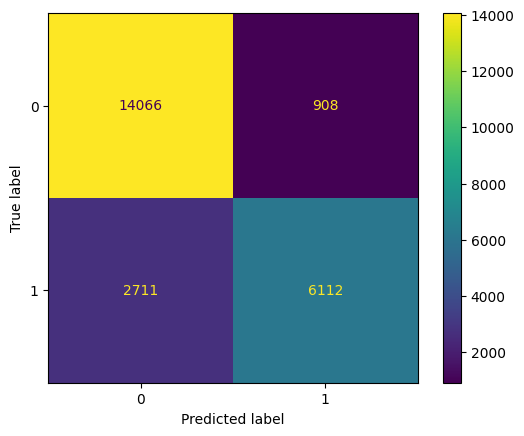

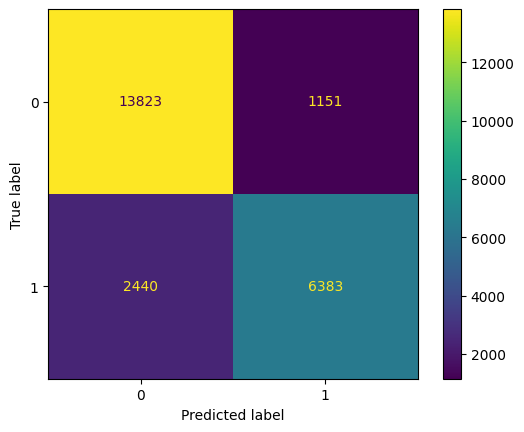

In [171]:
# Generamos una matriz de confusión que permitirá ver cuántas son las predicciones correctas y cuántas incorrectas
for model in y_preds:
    cm = confusion_matrix(y_test, y_preds[model][0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

- ROC (Receiver Operating Characteristic)

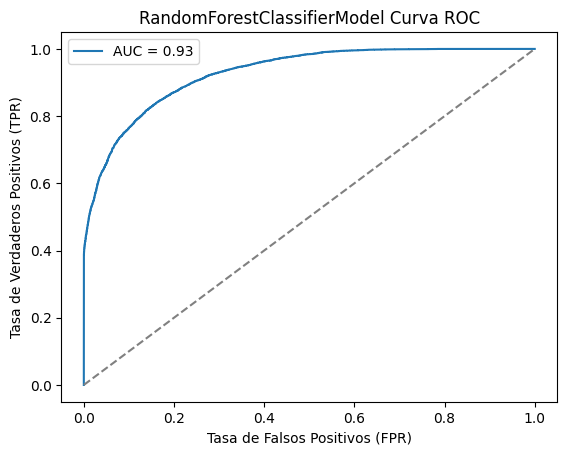

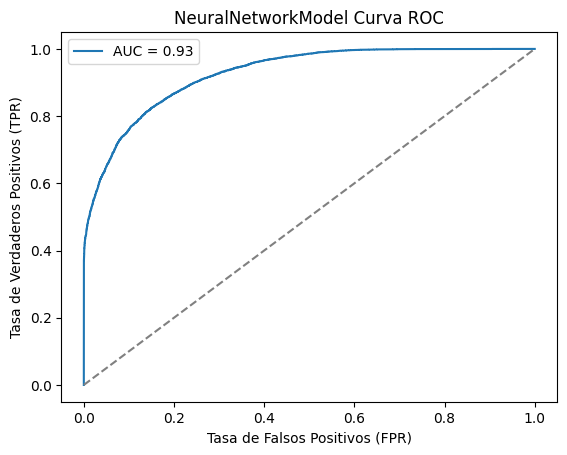

In [178]:
# Curva ROC
for model in y_preds:
    fpr, tpr, thresholds = roc_curve(y_test, y_preds[model][1])
    auc = roc_auc_score(y_test, y_preds[model][1])
    plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title(f'{model} Curva ROC')
    plt.legend()
    plt.show()

In [139]:
pd.Series(y_preds['RandomForestClassifierModel'][1][:,1])

0        0.135782
1        0.184548
2        0.339671
3        0.999325
4        0.325223
           ...   
23792    0.094245
23793    0.998630
23794    0.502534
23795    0.286902
23796    0.039880
Length: 23797, dtype: float64

In [173]:
for model in y_preds:
    print(y_preds[model][1])

0        0.168991
1        0.066320
2        0.327092
3        0.501178
4        0.148821
           ...   
23792    0.059444
23793    0.312694
23794    0.468577
23795    0.103493
23796    0.404999
Length: 23797, dtype: float64
0        0.041066
1        0.000795
2        0.162686
3        0.634293
4        0.106342
           ...   
23792    0.005908
23793    0.151610
23794    0.442589
23795    0.008968
23796    0.186768
Length: 23797, dtype: float32


In [174]:
y_test

99713     0
91659     0
22063     0
75532     1
99942     0
         ..
112552    0
70895     0
24807     0
77678     0
3225      0
Name: is_canceled, Length: 23797, dtype: int64